# DECISION TREE

Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("heart_disease (1).csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Exploratory Data Analysis (EDA):
        Perform exploratory data analysis to understand the structure of the dataset.

In [4]:
df.shape

(999, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [9]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Check for missing values, outliers, and inconsistencies in the data.

In [10]:
df.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns 

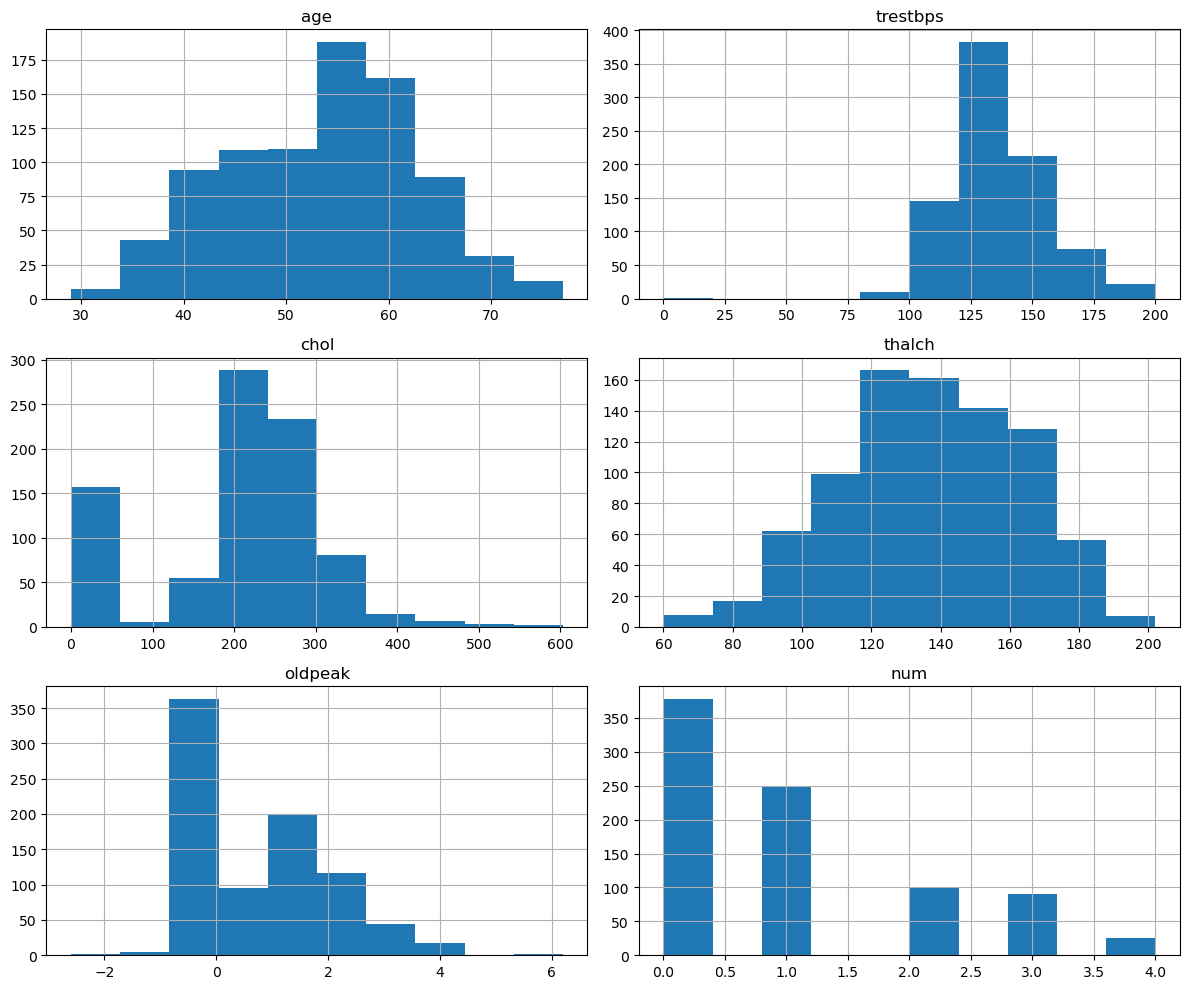

In [21]:
# Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

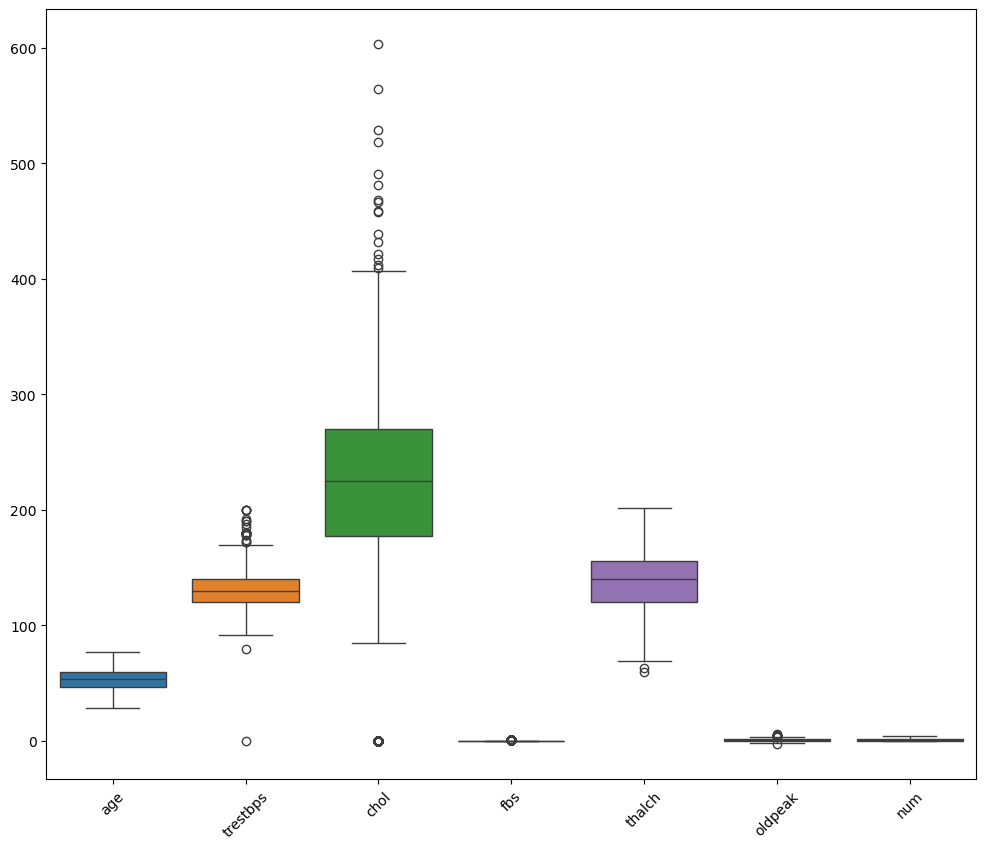

In [22]:
# Boxplot 
plt.figure(figsize=(12,10))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

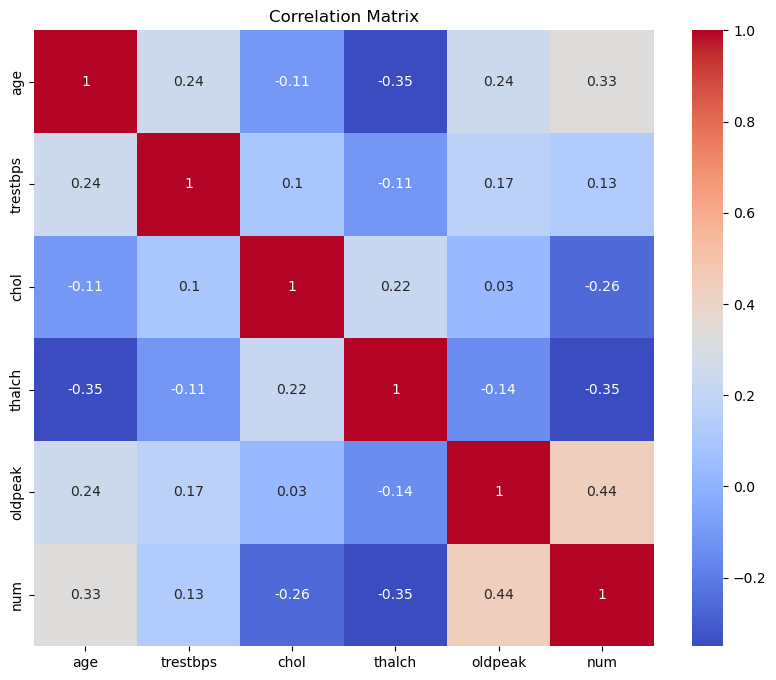

In [25]:
# Correlation Matrix
corr_matrix = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [26]:
# Outlier Detection using IQR
for col in df.select_dtypes(include=np.number).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) |
                  (df[col] > upper)]

    print(col, ":", len(outliers))

age : 0
trestbps : 30
chol : 173
thalch : 2
oldpeak : 16
num : 0


3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [29]:
df.select_dtypes(include='object').columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include = 'object').columns :
    df[col] = le.fit_transform(df[col])

4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
X = df.drop("num",axis=1)
y = df["num"]

In [34]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Implement a Decision Tree Classification model using a library like scikit-learn.

In [35]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

In [37]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
# Prediction 
y_pred = dt.predict(X_test)

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
# Accuracy
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy : ",accuracy)

Accuracy :  0.5352941176470588


In [42]:
from sklearn.metrics import precision_score

In [43]:
precision = precision_score( y_test , y_pred , average = 'weighted' )
print ("Precision : " , precision)

Precision :  0.5445557339689635


In [44]:
from sklearn.metrics import recall_score

In [45]:
recall = recall_score( y_test , y_pred , average = 'weighted')
print("Recall : ",recall)

Recall :  0.5352941176470588


In [46]:
from sklearn.metrics import f1_score

In [47]:
f1 = f1_score( y_test , y_pred , average='weighted')
print("f1 Score :",f1)

f1 Score : 0.5247211096519961


In [48]:
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.72      0.71      0.72        80
         1.0       0.38      0.56      0.45        41
         2.0       0.33      0.36      0.34        14
         3.0       0.55      0.22      0.32        27
         4.0       0.00      0.00      0.00         8

    accuracy                           0.54       170
   macro avg       0.40      0.37      0.37       170
weighted avg       0.54      0.54      0.52       170



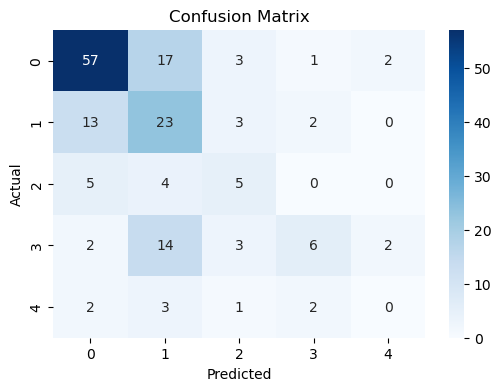

In [50]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score
y_prob = dt.predict_proba(X_test)

roc = roc_auc_score(y_test, y_prob , multi_class='ovr',
    average='weighted')

print("ROC-AUC:", roc)

ROC-AUC: 0.6686114775262061


5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [56]:
depths = [3,5,7,10]

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print(
        "Depth:",
        d,
        "Accuracy:",
        accuracy_score(y_test,pred)
    )

Depth: 3 Accuracy: 0.5764705882352941
Depth: 5 Accuracy: 0.5823529411764706
Depth: 7 Accuracy: 0.5764705882352941
Depth: 10 Accuracy: 0.5823529411764706


In [57]:
for c in ['gini','entropy']:

    model = DecisionTreeClassifier(
        criterion=c,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print(
        c,
        accuracy_score(y_test,pred)
    )

gini 0.5352941176470588
entropy 0.5058823529411764


6. Model Evaluation and Analysis:

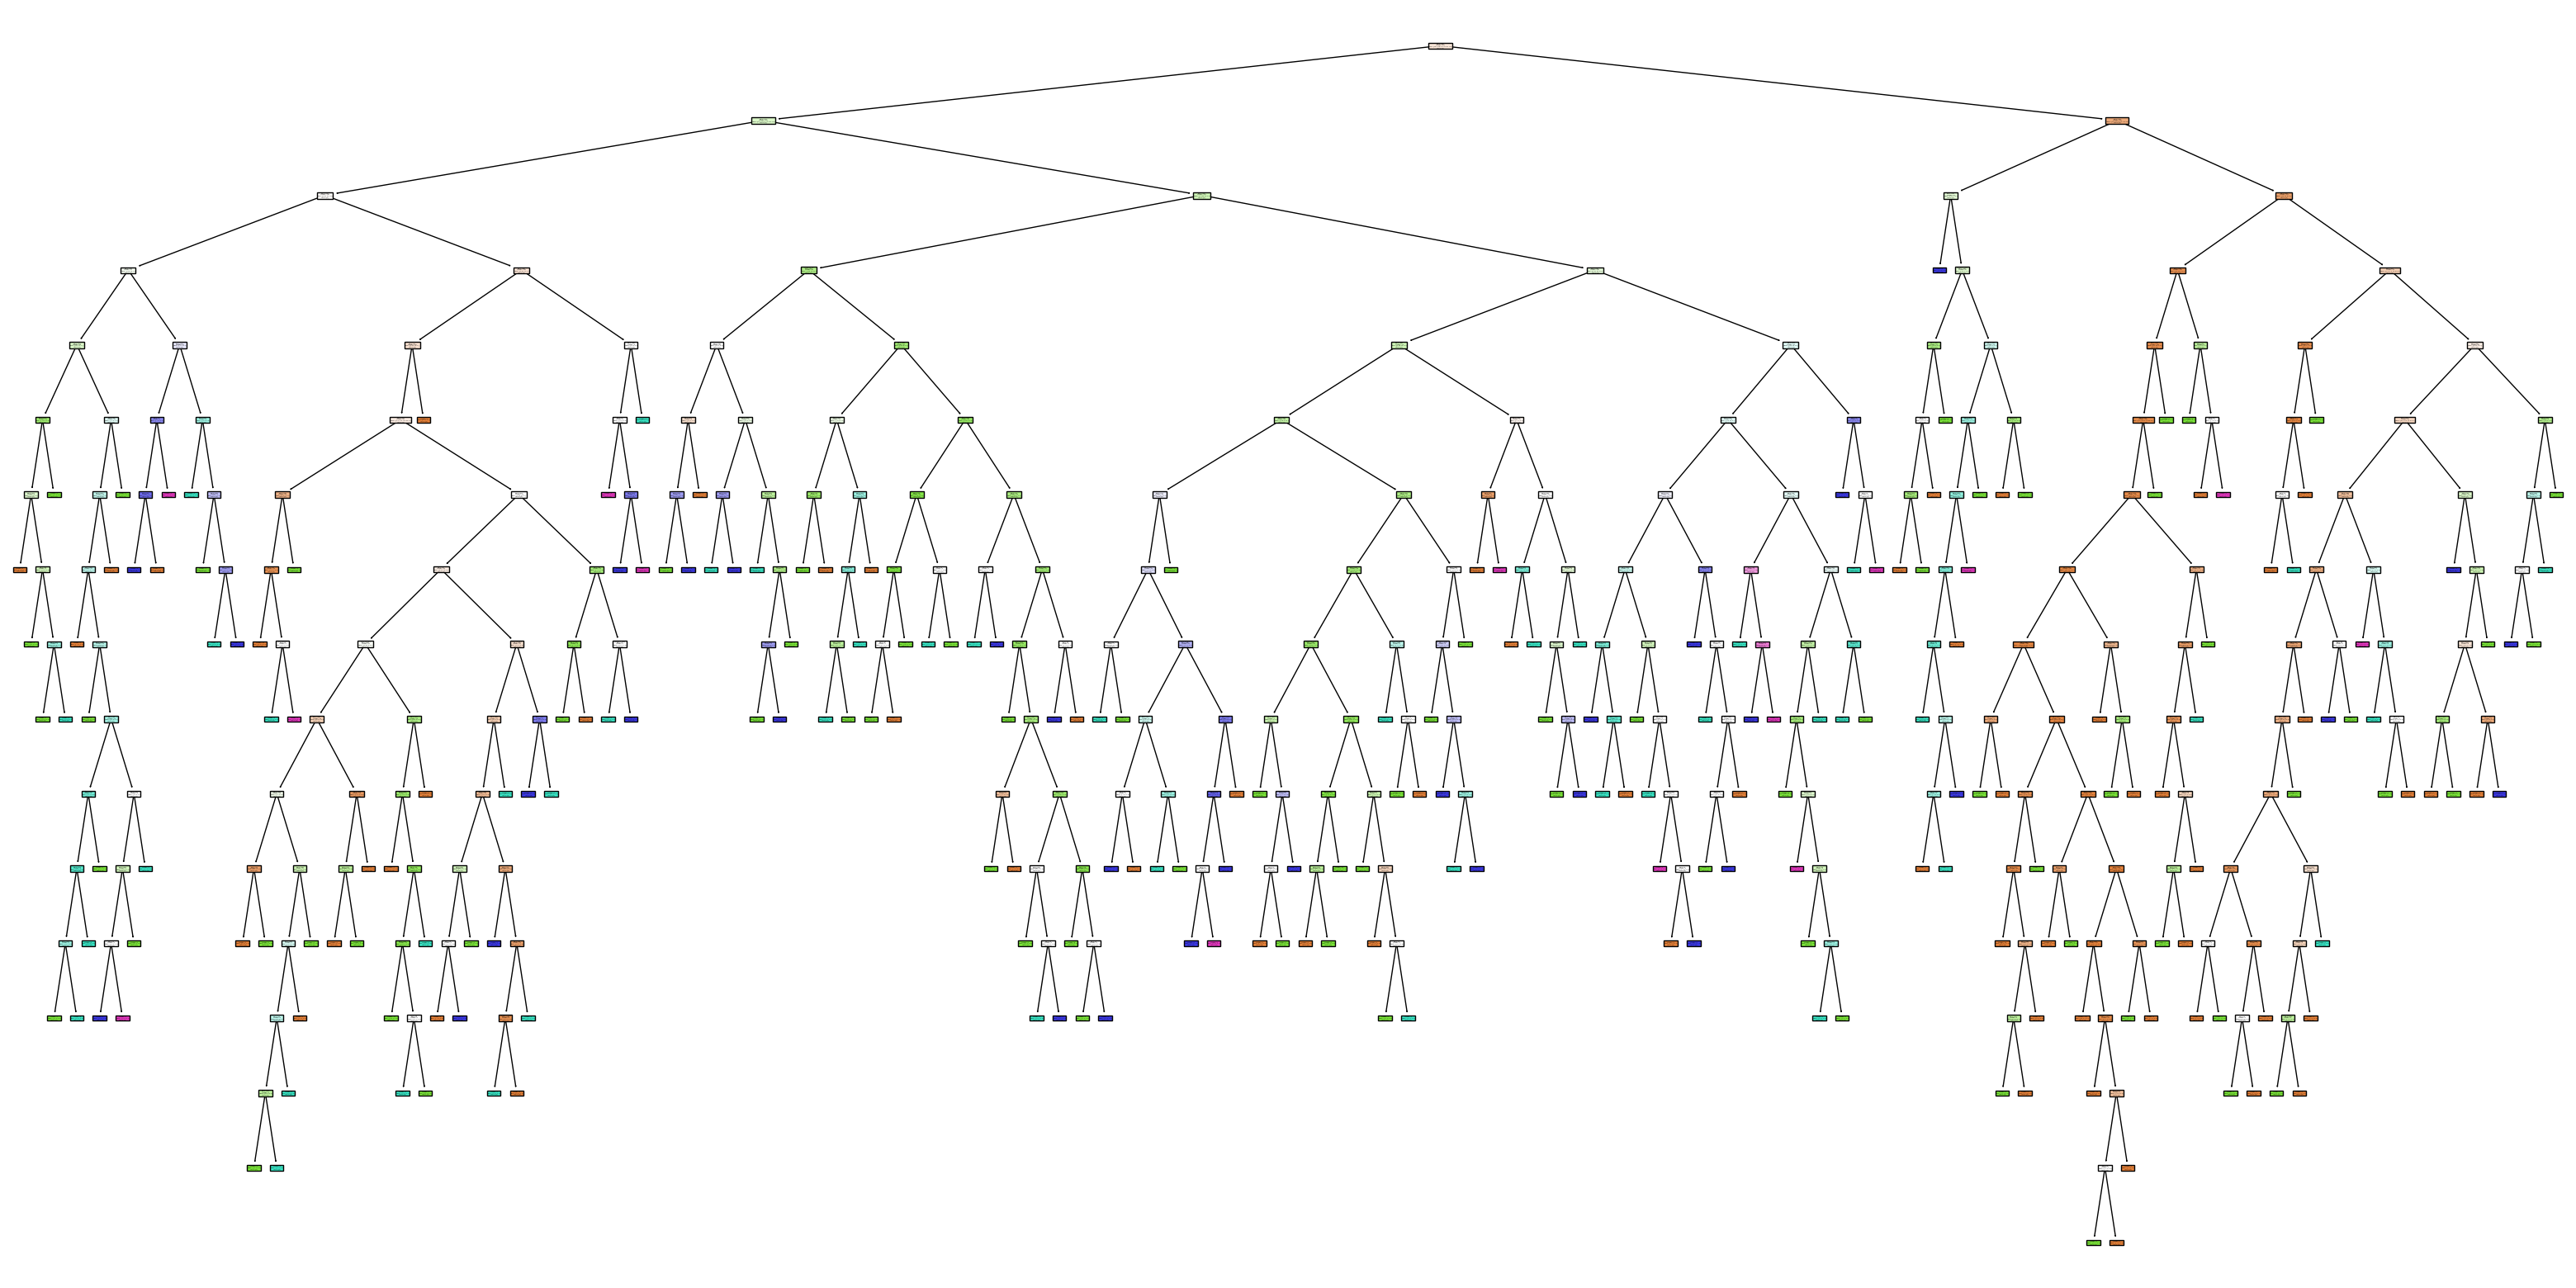

In [59]:
plt.figure(figsize=(40,20))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.show()

In [60]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
4       chol    0.185207
7     thalch    0.170655
2         cp    0.140082
0        age    0.113452
9    oldpeak    0.112887
3   trestbps    0.104601
6    restecg    0.037249
10     slope    0.036773
11      thal    0.032003
1        sex    0.031207
8      exang    0.024600
5        fbs    0.011284


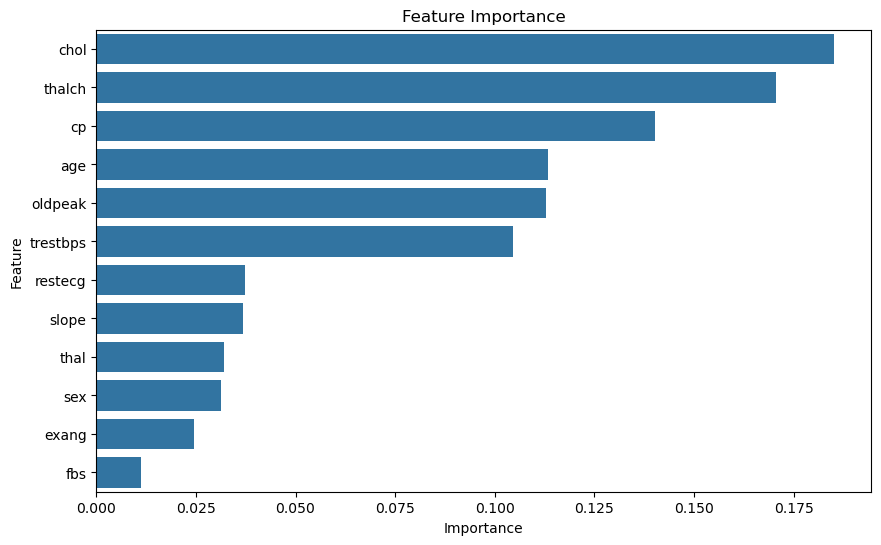

In [61]:
#Bar Graph
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Conclusion :

Decision Tree classifier was successfully implemented.
EDA was performed to understand data distribution.
Model performance was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
Hyperparameter tuning improved performance.
Decision Tree visualization helped understand decision rules.
Feature importance identified the most influential attributes.

# Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Hyperparameters are settings that control how a Decision Tree is built. Important hyperparameters include:

max_depth :: 
Specifies the maximum depth of the tree.
A larger depth can increase accuracy but may cause overfitting.
A smaller depth reduces complexity and helps prevent overfitting.

min_samples_split :: 
Minimum number of samples required to split an internal node.
Higher values create simpler trees and reduce overfitting.
Lower values allow more splits and may increase overfitting.

min_samples_leaf ::
Minimum number of samples required at a leaf node.
Larger values make the model more generalized.
Smaller values may capture noise in the data.

criterion ::
Measures the quality of a split.
Common values:
gini: Uses Gini Impurity.
entropy: Uses Information Gain.
Different criteria may produce slightly different trees.

max_features :: 
Maximum number of features considered for splitting.
Reduces computation and can help prevent overfitting.

splitter :: 
Strategy used to choose the split at each node.
best: Selects the best split.
random: Selects a random split, increasing randomness.

2. What is the difference between the Label encoding and One-hot encoding?

Label Encoding             

| ----------------------------------------------------|

Converts each category into a unique integer value.    
Example: Male = 0, Female = 1                          
Uses less memory and fewer columns.                    
May introduce an artificial order among categories.  
Suitable for ordinal data (e.g., Low, Medium, High). 



One-Hot Encoding

| ------------------------------------------------------ |

Creates a separate binary column for each category.                                                                                                     
Example: Male → [1,0], Female → [0,1].

Uses more memory because it creates multiple columns.

Does not introduce any order among categories.

Suitable for nominal data (e.g., Color, Gender, City).